In [1]:
# iMPORT & LOAD DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# Load RFM data
df = pd.read_csv("D:/customer-segmentation-unsupervised/data/processed/rfm_data.csv")

# Remove user_id if present
if "user_id" in df.columns:
    df = df.drop(columns=["user_id"])

# Scale data
scaler = StandardScaler()
X = scaler.fit_transform(df)

print("Data Ready ")

Data Ready 


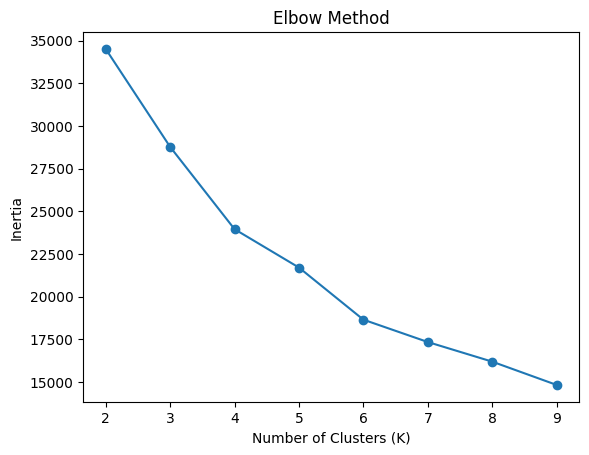

In [2]:
# ELBOW METHOD
from sklearn.cluster import KMeans

inertia = []

k_range = range(2, 10)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X)
    inertia.append(model.inertia_)

# Plot
plt.figure()
plt.plot(k_range, inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

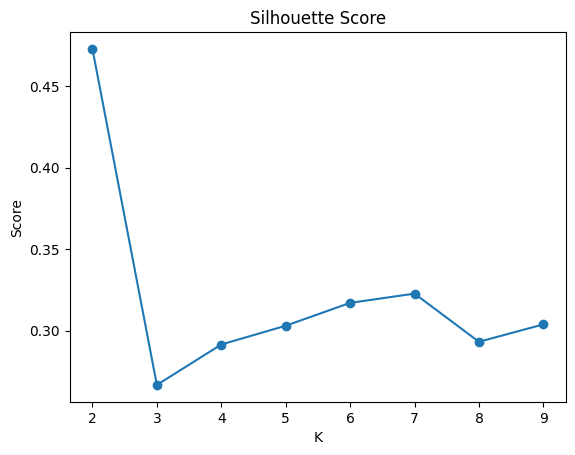

In [3]:
# SILHOUETTE SCORE
from sklearn.metrics import silhouette_score

sil_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = silhouette_score(X, labels)
    sil_scores.append(score)

# Plot
plt.figure()
plt.plot(k_range, sil_scores, marker='o')
plt.title("Silhouette Score")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

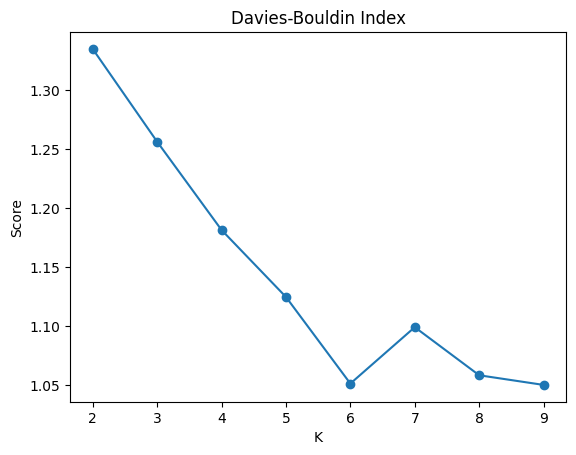

In [4]:
# DAVIES-BOULDIN INDEX
from sklearn.metrics import davies_bouldin_score

db_scores = []

for k in k_range:
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X)
    score = davies_bouldin_score(X, labels)
    db_scores.append(score)

# Plot
plt.figure()
plt.plot(k_range, db_scores, marker='o')
plt.title("Davies-Bouldin Index")
plt.xlabel("K")
plt.ylabel("Score")
plt.show()

In [5]:
print("Optimal number of clusters chosen: 4")

Optimal number of clusters chosen: 4


In [6]:
# Save Silhouette Scores
import pandas as pd
import os

os.makedirs("D:/customer-segmentation-unsupervised/results/metrics", exist_ok=True)

sil_df = pd.DataFrame({
    "K": list(k_range),
    "Silhouette Score": sil_scores
})

sil_df.to_csv("D:/customer-segmentation-unsupervised/results/metrics/silhouette_scores.csv", index=False)

In [7]:
# Save Davies-Bouldin Index
db_df = pd.DataFrame({
    "K": list(k_range),
    "DB Index": db_scores
})

db_df.to_csv("D:/customer-segmentation-unsupervised/results/metrics/db_index.csv", index=False)

In [8]:
# Save Inertia (Elbow)
inertia_df = pd.DataFrame({
    "K": list(k_range),
    "Inertia": inertia
})

inertia_df.to_csv("D:/customer-segmentation-unsupervised/results/metrics/inertia_values.csv", index=False)